In [1]:
# import necessary libraries:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import os

https://yellowplannet.com/time-series-data-labeling/

In [2]:
# run code from data_input folder:
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')


In [3]:
# --- Data Upload ---
def load_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    return df

file_path = ('factor_benchmark_returns.csv')
df=load_data(file_path)

# Ensure data type is: float
print(df.dtypes)

Momentum      float64
Value         float64
Quality       float64
Benchmarks    float64
dtype: object


In [4]:
# --- Relative Returns Calculation ---
def relative_returns(df):
    for factor in ['Momentum', 'Value', 'Quality']:
        df[f'{factor}_Relative'] = df[factor] - df['Benchmarks']
    return df

df_rel_returns = relative_returns(df)
print(df_rel_returns)

            Momentum   Value  Quality  Benchmarks  Momentum_Relative  \
Date                                                                   
2004-01-01    0.0103  0.0316      NaN    0.037828          -0.027528   
2004-02-01    0.0157  0.0102      NaN   -0.001956           0.017656   
2004-03-01    0.0147  0.0139      NaN    0.003079           0.011621   
2004-04-01   -0.0227  0.0068      NaN   -0.017248          -0.005452   
2004-05-01    0.0018  0.0034      NaN    0.005029          -0.003229   
...              ...     ...      ...         ...                ...   
2025-01-01   -0.0233  0.0083   0.0044    0.025600          -0.048900   
2025-02-01    0.0066 -0.0067  -0.0240   -0.003800           0.010400   
2025-03-01    0.0816  0.0228   0.0336    0.036100           0.045500   
2025-04-01    0.0581  0.0557   0.0425    0.042700           0.015400   
2025-05-01    0.0246  0.0193   0.0274    0.030400          -0.005800   

            Value_Relative  Quality_Relative  
Date            

In [5]:
# --- Cumulative Relative Returns Calculation ---
def cumulative_relative_returns(df):
    for factor in ['Momentum', 'Value', 'Quality']:
        # Calculate cumulative product of (1 + relative return)
        cumulative_returns = (1 + df[f'{factor}_Relative']).cumprod() - 1
        df[f'{factor}_Cumulative_Relative'] = cumulative_returns
    return df

# Apply the function to your dataframe
df_cumulative = cumulative_relative_returns(df_rel_returns)
print(df_cumulative)

            Momentum   Value  Quality  Benchmarks  Momentum_Relative  \
Date                                                                   
2004-01-01    0.0103  0.0316      NaN    0.037828          -0.027528   
2004-02-01    0.0157  0.0102      NaN   -0.001956           0.017656   
2004-03-01    0.0147  0.0139      NaN    0.003079           0.011621   
2004-04-01   -0.0227  0.0068      NaN   -0.017248          -0.005452   
2004-05-01    0.0018  0.0034      NaN    0.005029          -0.003229   
...              ...     ...      ...         ...                ...   
2025-01-01   -0.0233  0.0083   0.0044    0.025600          -0.048900   
2025-02-01    0.0066 -0.0067  -0.0240   -0.003800           0.010400   
2025-03-01    0.0816  0.0228   0.0336    0.036100           0.045500   
2025-04-01    0.0581  0.0557   0.0425    0.042700           0.015400   
2025-05-01    0.0246  0.0193   0.0274    0.030400          -0.005800   

            Value_Relative  Quality_Relative  Momentum_Cumulati

In [6]:
# --- Trend Scanning Functions ---
def tval_lin(close):

    # Computes t-values on sample determined by look-forward window L
    x = np.ones((close.shape[0], 2))
    x[:, 1] = np.arange(close.shape[0])
    ols = sm.OLS(close, x).fit()
    return ols.tvalues[1]

def get_bins(molecule, close, span):
    # Pick the value of L that maximizes t-values

    out = pd.DataFrame(index=molecule, columns=['t1', 'tval', 'bin'])
    hrzns = range(*span)
    
    for dt0 in molecule:
        df0 = pd.Series(dtype=float)
        iloc0 = close.index.get_loc(dt0)
        
        if iloc0 + max(hrzns) > len(close):
            continue
            
        for hrzn in hrzns:
            dt1 = close.index[iloc0 + hrzn - 1]
            df1 = close.loc[dt0:dt1]
            df0.loc[dt1] = tval_lin(df1.values)
            
        if not df0.empty:
            dt1 = df0.replace([-np.inf, np.inf, np.nan], 0).abs().idxmax()
            tval = df0[dt1]
            
            # Create binary label based on t-value significance and sign
            if abs(tval) >= 0:
                bin_label = 1 if tval > 0 else 0  # 1=up, 0=down
            else:
                bin_label = np.nan  # Not significant, will be dropped
                
            out.loc[dt0, ['t1', 'tval', 'bin']] = dt1, tval, bin_label


    out['t1'] = pd.to_datetime(out['t1'])
    out['bin'] = pd.to_numeric(out['bin'], downcast='signed')
    return out.dropna(subset=['bin'])


In [7]:
# --- Execute ---
if __name__ == "__main__":
    # Load data
    file_path = 'factor_benchmark_returns.csv'
    df = load_data(file_path)
    
    # Calculate relative returns
    df = relative_returns(df)

    # Calculate relative returns
    df = cumulative_relative_returns(df)
    
    # Apply trend scanning to each factor
    span = (1, 12)  # Look-forward window range
    
    for factor in ['Momentum', 'Value', 'Quality']:
        col_name = f'{factor}_Cumulative_Relative'
        molecule = df[col_name].index 
        
        # Get trend labels
        trend_labels = get_bins(molecule, df[col_name], span)
        
        # Merge labels back to original DataFrame
        df = df.join(trend_labels.add_prefix(f'{factor}_'), how='left')
        
        print(f"\nTrend Scanning Results for {factor}:")
        print(trend_labels.describe())
    
    # Save results
    df.to_csv('labeled_data.csv')
    print("\nLabeled data saved to 'labeled_data.csv'")


Trend Scanning Results for Momentum:
                                  t1         bin
count                            247  247.000000
mean   2014-09-30 20:59:16.275303680    0.655870
min              2004-03-01 00:00:00    0.000000
25%              2009-06-16 00:00:00    0.000000
50%              2014-12-01 00:00:00    1.000000
75%              2020-02-01 00:00:00    1.000000
max              2024-12-01 00:00:00    1.000000
std                              NaN    0.476048

Trend Scanning Results for Value:
                                  t1         bin
count                            247  247.000000
mean   2014-09-23 10:47:07.530364416    0.514170
min              2004-03-01 00:00:00    0.000000
25%              2009-09-01 00:00:00    0.000000
50%              2014-09-01 00:00:00    1.000000
75%              2020-01-01 00:00:00    1.000000
max              2024-12-01 00:00:00    1.000000
std                              NaN    0.500814

Trend Scanning Results for Quality:
        

In [8]:
# --- Visualization Functions ---
def plot_trend_labels(factor, cumulative_relative_returns, labels, save_path=None):
    """Plot relative returns with trend markers overlay"""
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot relative returns
    ax.plot(cumulative_relative_returns.index, cumulative_relative_returns, 
            color='steelblue', label='Relative Returns', linewidth=1.5)
    
    # Plot trend markers
    for idx, row in labels.iterrows():
        if row['bin'] == 1:  # Upward trend
            ax.plot(idx, cumulative_relative_returns.loc[idx], 
                   marker='^', color='green', markersize=8, 
                   label='Up Trend' if idx == labels.index[0] else "")
        elif row['bin'] == 0:  # Downward trend
            ax.plot(idx, cumulative_relative_returns.loc[idx], 
                   marker='v', color='red', markersize=8,
                   label='Down Trend' if idx == labels.index[0] else "")
    
    # Add horizontal line at zero
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    
    # Formatting
    ax.set_xlabel('Date')
    ax.set_ylabel('Relative Returns')
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    
    # Title and legend
    plt.title(f'Trend Scanning Labels vs Relative Returns: {factor}')
    ax.legend(loc='upper left')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


Processing Momentum...
Saved momentum_labeled.csv


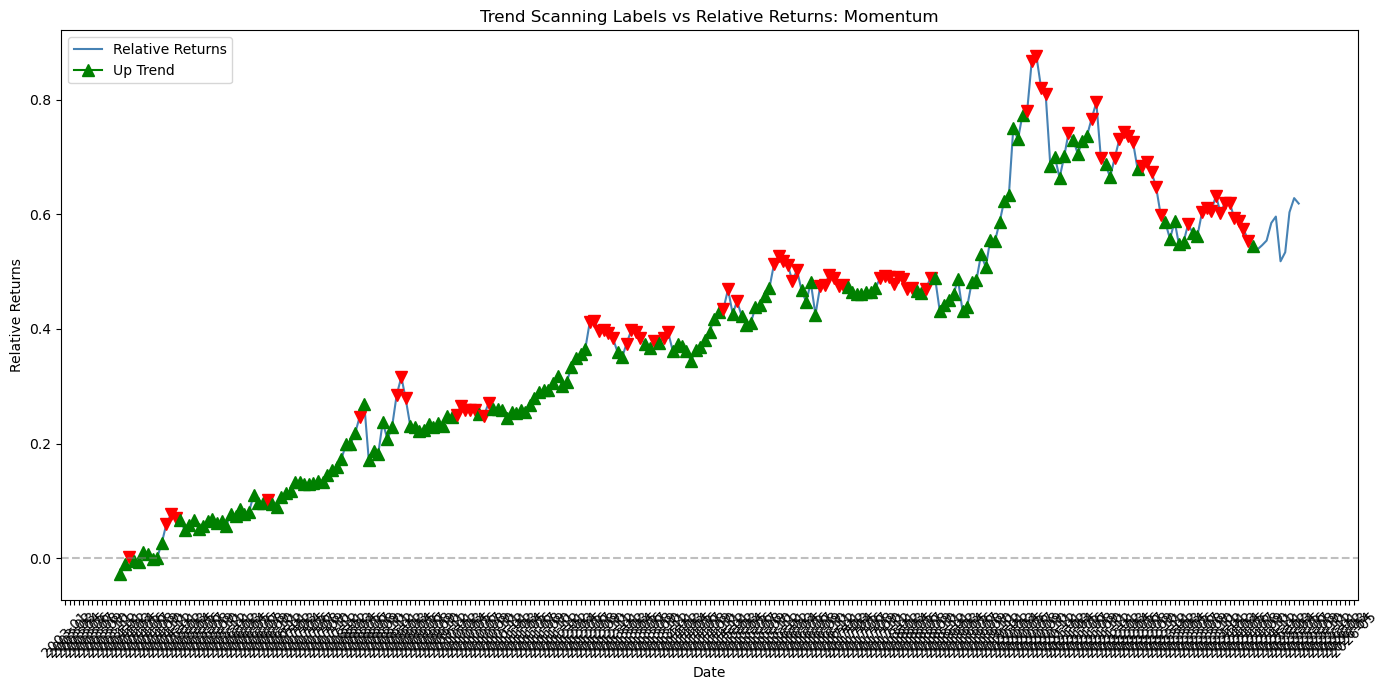

Saved momentum_trend_plot.png

Processing Value...
Saved value_labeled.csv


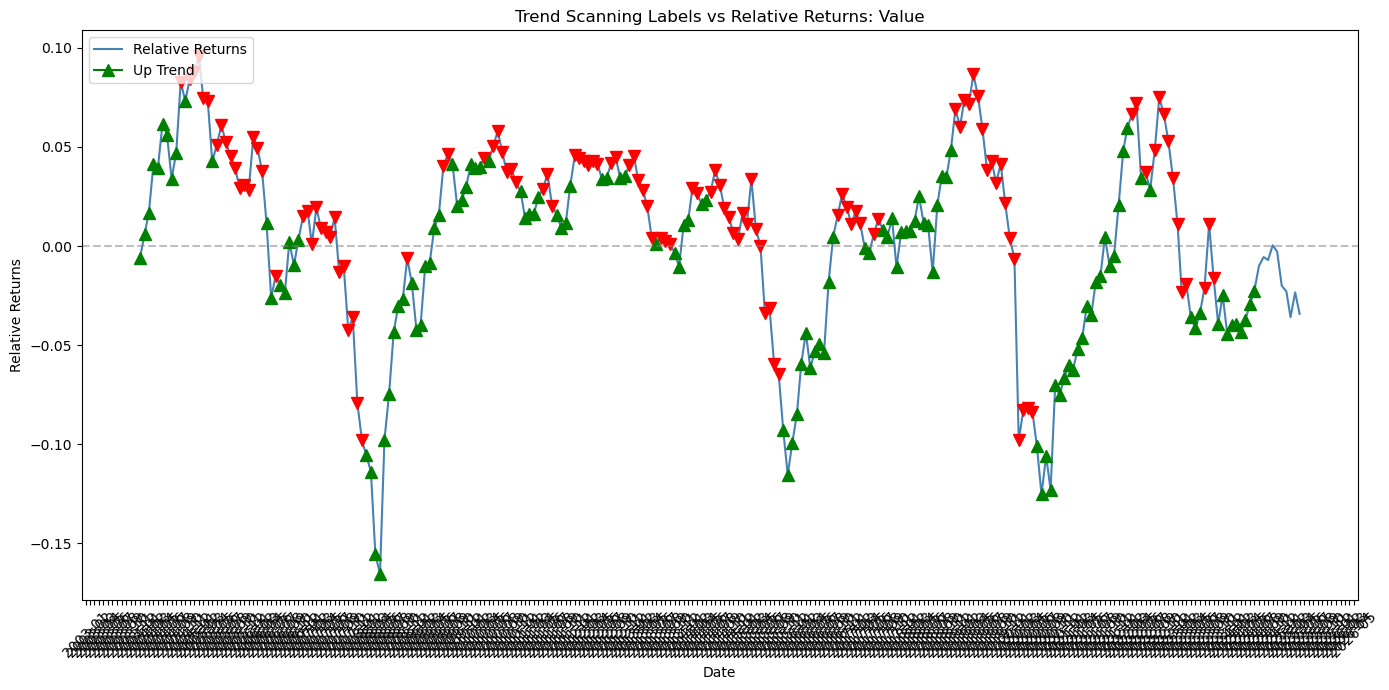

Saved value_trend_plot.png

Processing Quality...
Saved quality_labeled.csv


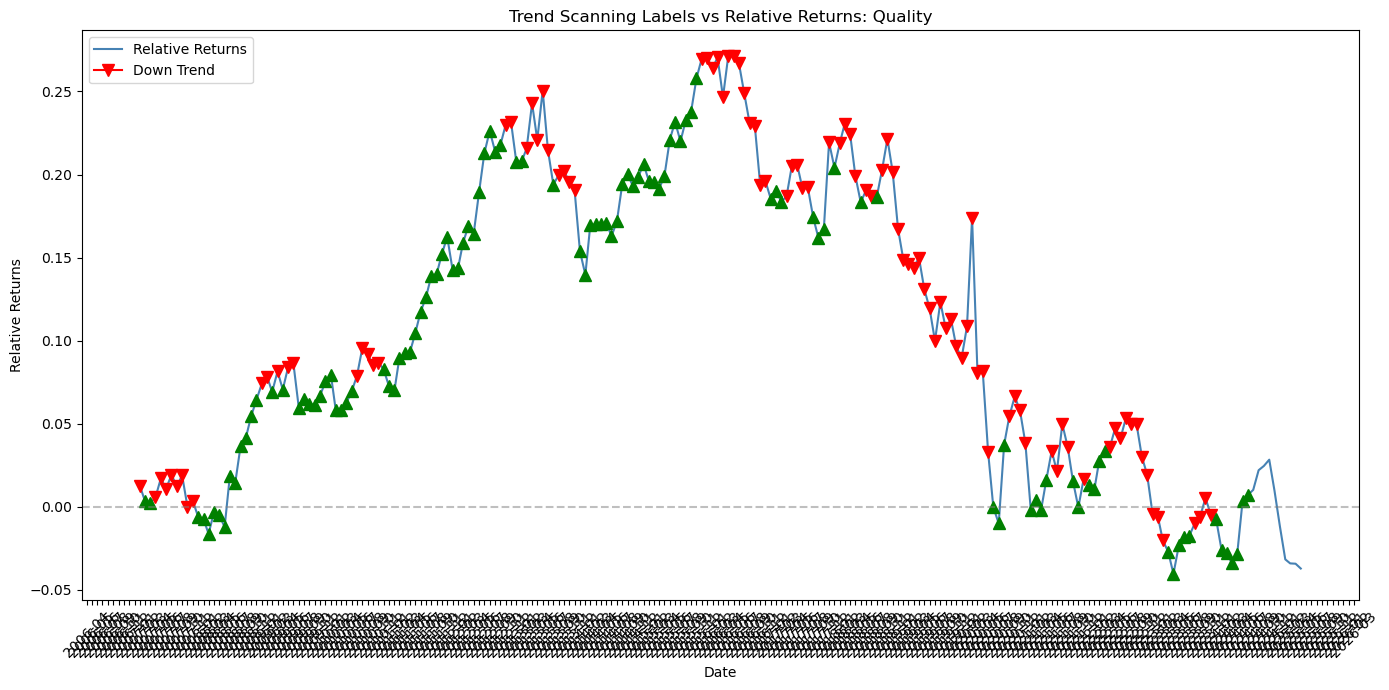

Saved quality_trend_plot.png

Processing complete!


In [9]:
# --- Main Execution ---
if __name__ == "__main__":
    # 1. Load data
    file_path = 'factor_benchmark_returns.csv'  # Replace with your file path
    df = load_data(file_path)
    
    # 2. Calculate relative returns
    df = relative_returns(df)

    # 3. Calculate relative returns
    df = cumulative_relative_returns(df)
    
    # 4. Apply trend scanning to each factor
    span = (1, 12)  # Look-forward window range (min, max+1)
    
    for factor in ['Momentum', 'Value', 'Quality']:
        print(f"\nProcessing {factor}...")
        col_name = f'{factor}_Cumulative_Relative'
        molecule = df[col_name].index  # All dates as potential start points
        
        # Get trend labels
        trend_labels = get_bins(molecule, df[col_name], span)
        
        # Save factor-specific data
        factor_df = df[[factor, 'Benchmarks', col_name]].join(trend_labels.add_prefix('trend_'))
        factor_df.to_csv(f'{factor.lower()}_labeled.csv')
        print(f"Saved {factor.lower()}_labeled.csv")
        
        # Generate visualization
        plot_trend_labels(
            factor=factor,
            cumulative_relative_returns=df[col_name],
            labels=trend_labels,
            save_path=f'{factor.lower()}_trend_plot.png'
        )
        print(f"Saved {factor.lower()}_trend_plot.png")
    
    print("\nProcessing complete!")
